In [1]:
import os
import sys
import joblib
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score

# Add project root
sys.path.append(os.path.abspath(".."))

from src.utils import project_name

print(project_name())
print("Notebook 04 - Model Training")

FairHire
Notebook 04 - Model Training


In [11]:
# 2. Load the training and testing data
X_train = joblib.load("../models/X_train.pkl")
X_test = joblib.load("../models/X_test.pkl")

y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (8139, 5000)
Testing Set  : (2035, 5000)


In [12]:
# 3. Create a Dictionary for Results
model_scores = {}
trained_models = {}

In [33]:
# 4. Train Logistic Regression and Evaluate Models
import time

start = time.time()

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train, y_train)

end = time.time()

predictions = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

model_scores["Logistic Regression"] = {
    "Accuracy": accuracy,
    "Training Time": end - start
}

trained_models["Logistic Regression"] = log_reg

print(f"Accuracy      : {accuracy:.4f}")
print(f"Training Time : {end - start:.4f} seconds")

Accuracy      : 0.5799
Training Time : 0.1733 seconds


In [5]:
# 4.1. Create a DataFrame for Predictions (Check the prediction distribution)
import pandas as pd

prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

print(prediction_df.head())

print("\nPrediction Distribution")
print(prediction_df["Predicted"].value_counts())

      Actual  Predicted
8915       1          1
4463       1          1
1684       1          1
5141       0          0
735        1          1

Prediction Distribution
Predicted
0    1030
1    1005
Name: count, dtype: int64


In [6]:
# 4.2. Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.58      0.59      0.58      1023
           1       0.58      0.57      0.58      1012

    accuracy                           0.58      2035
   macro avg       0.58      0.58      0.58      2035
weighted avg       0.58      0.58      0.58      2035



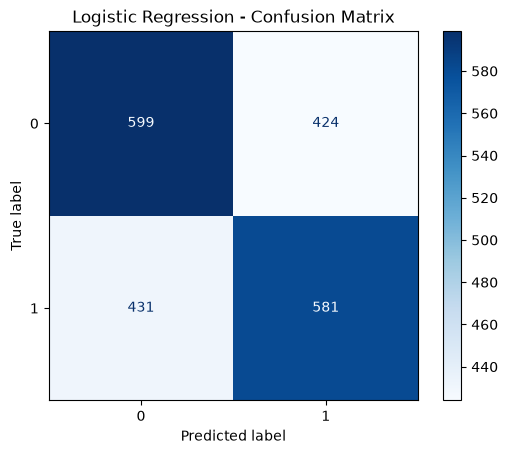

In [7]:
# 4.3. Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    log_reg,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [31]:
# 5. Train Dummy Classifier and Evaluate Models
import time
from sklearn.dummy import DummyClassifier

start = time.time()

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

end = time.time()

dummy_predictions = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_predictions)

model_scores["Dummy Classifier"] = {
    "Accuracy": dummy_accuracy,
    "Training Time": end - start
}

trained_models["Dummy Classifier"] = dummy_model

print(f"Accuracy      : {dummy_accuracy:.4f}")
print(f"Training Time : {end - start:.4f} seconds")

Accuracy      : 0.5027
Training Time : 0.0009 seconds


In [32]:
# 6. Train Multinomial Naive Bayes and Evaluate Models
import time
from sklearn.naive_bayes import MultinomialNB

start = time.time()

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

end = time.time()

nb_predictions = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_predictions)

model_scores["Multinomial Naive Bayes"] = {
    "Accuracy": nb_accuracy,
    "Training Time": end - start
}

trained_models["Multinomial Naive Bayes"] = nb_model

print(f"Accuracy      : {nb_accuracy:.4f}")
print(f"Training Time : {end - start:.4f} seconds")

Accuracy      : 0.5705
Training Time : 0.0068 seconds


In [34]:
# 7. Train Random Forest Classifier and Evaluate Models
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

end = time.time()

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

model_scores["Random Forest"] = {
    "Accuracy": rf_accuracy,
    "Training Time": end - start
}

trained_models["Random Forest"] = rf_model

print(f"Accuracy      : {rf_accuracy:.4f}")
print(f"Training Time : {end - start:.4f} seconds")

Accuracy      : 0.5808
Training Time : 4.3578 seconds


In [35]:
# 8. Train Linear SVM and Evaluate Models
import time
from sklearn.svm import LinearSVC

start = time.time()

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train, y_train)

end = time.time()

svm_predictions = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_predictions)

model_scores["Linear SVM"] = {
    "Accuracy": svm_accuracy,
    "Training Time": end - start
}

trained_models["Linear SVM"] = svm_model

print(f"Accuracy      : {svm_accuracy:.4f}")
print(f"Training Time : {end - start:.4f} seconds")

Accuracy      : 0.5759
Training Time : 0.9973 seconds


In [36]:
# 9. Compare All Models
results_df = (
    pd.DataFrame(model_scores)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Training Time
0,Random Forest,0.580835,4.357792
1,Logistic Regression,0.579853,0.173263
2,Linear SVM,0.575921,0.997323
3,Multinomial Naive Bayes,0.570516,0.006837
4,Dummy Classifier,0.502703,0.000902


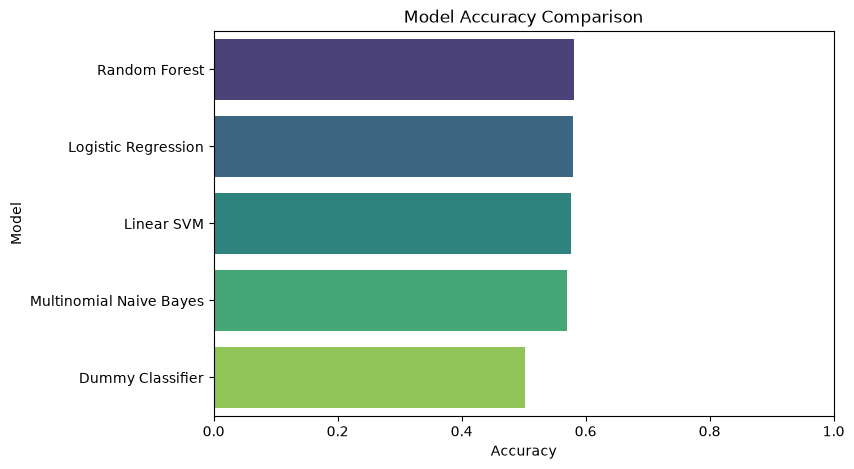

In [38]:
# 10. Visualize Model Accuracy Comparison
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

In [40]:
# 11. Save Trained Models
import os
import joblib

os.makedirs("../models/trained_models", exist_ok=True)

for model_name, model in trained_models.items():
    filename = model_name.lower().replace(" ", "_") + ".pkl"
    joblib.dump(model, f"../models/trained_models/{filename}")

print("All trained models saved successfully.")

All trained models saved successfully.


# **Model Training Summary**

## Objective

The objective of this notebook was to train and compare multiple machine learning algorithms for the resume classification task. Each model was trained using TF-IDF features generated from the preprocessed resume text.

---

## Models Trained

The following supervised learning algorithms were evaluated:

- Logistic Regression
- Dummy Classifier (Baseline)
- Multinomial Naive Bayes
- Random Forest
- Linear Support Vector Machine (Linear SVM)

---

## Performance Comparison

| Model | Observation |
|--------|-------------|
| Random Forest | Highest classification accuracy among all evaluated models. |
| Logistic Regression | Comparable accuracy with significantly lower training time. |
| Linear SVM | Produced competitive results with moderate training time. |
| Multinomial Naive Bayes | Fastest probabilistic model with slightly lower accuracy. |
| Dummy Classifier | Baseline model used for comparison. |

---

## Key Findings

- All trained machine learning models outperformed the Dummy Classifier baseline.
- The performance difference among the four trained models was relatively small.
- Random Forest achieved the highest accuracy, while Logistic Regression demonstrated the best balance between accuracy and computational efficiency.
- The similar performance across multiple algorithms suggests that the current dataset is the primary limiting factor rather than the choice of classifier.

---

## Conclusion

The trained models provide a reliable baseline for the FairHire resume screening system. The best-performing model will be selected for detailed evaluation in the next notebook, where additional metrics such as Precision, Recall, F1-score, Confusion Matrix, and Explainable AI techniques will be applied.